## 04.5 Pathway-Aware Fusion Analysis

Comparison of **PathwayAwareFusionModel** (KEGG pathway attention for mRNA)
against **IntermediateFusionModel** (plain dense encoder).

Academic research prototype. Not for clinical use.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os

# Ensure we run from project root regardless of where Jupyter was launched
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir(project_root)
print(f'Working directory: {os.getcwd()}')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 150

Working directory: c:\Users\dneth\Downloads\multi-omics-cancer-subtype-classifier


### 1. Pathway Mapping Coverage

In [2]:
with open('data/processed/pathway_gene_mapping.json', 'r') as f:
    mapping = json.load(f)

for cancer in ['BRCA', 'COAD']:
    m = mapping[cancer]
    print(f"{cancer}: {m['n_pathways_with_hits']} pathways, "
          f"{m['n_mapped_features']} mapped / {m['n_unmapped_features']} unmapped "
          f"({m['coverage_pct']}% coverage)")

BRCA: 311 pathways, 1759 mapped / 3241 unmapped (35.18% coverage)
COAD: 310 pathways, 1874 mapped / 3126 unmapped (37.48% coverage)


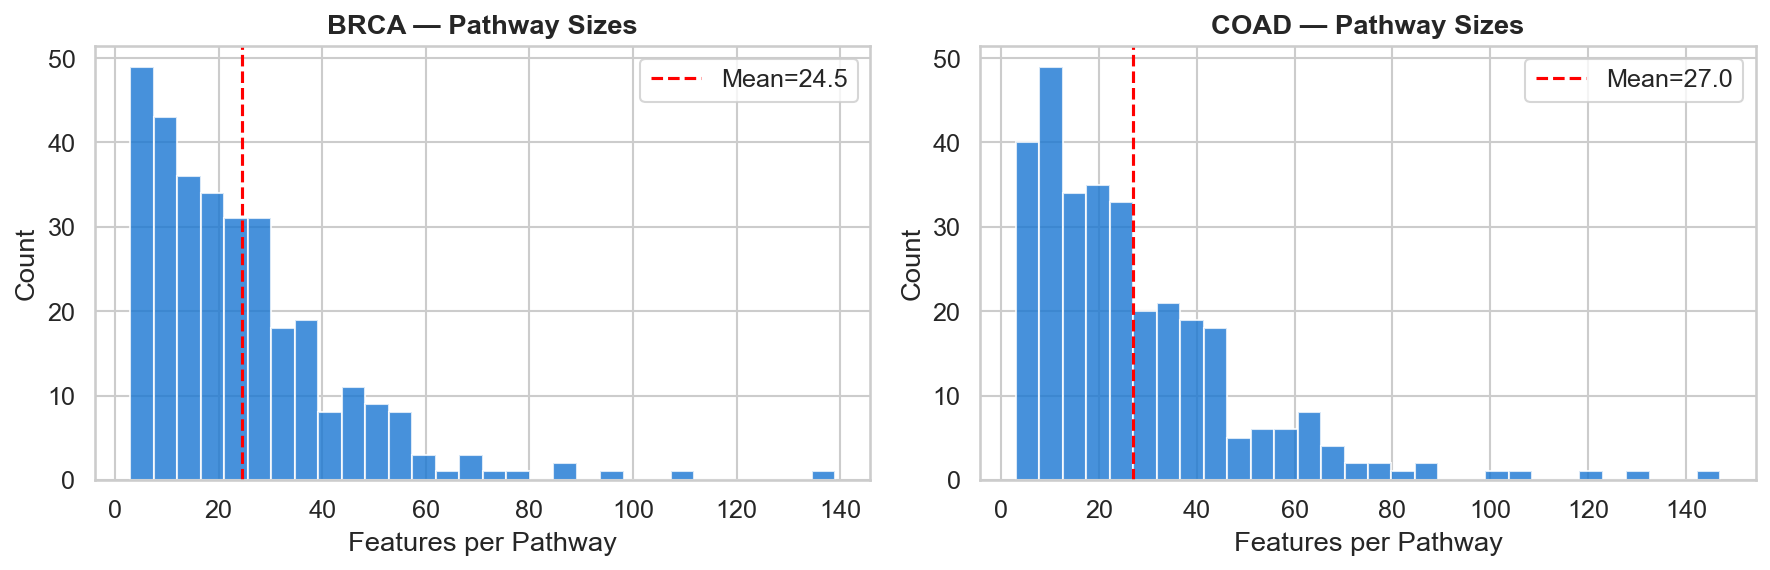

In [3]:
# Pathway size distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, cancer in enumerate(['BRCA', 'COAD']):
    sizes = [len(v) for v in mapping[cancer]['pathways'].values()]
    axes[i].hist(sizes, bins=30, color='#1976D2', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'{cancer} \u2014 Pathway Sizes', fontweight='bold')
    axes[i].set_xlabel('Features per Pathway')
    axes[i].set_ylabel('Count')
    axes[i].axvline(np.mean(sizes), color='red', linestyle='--',
                    label=f'Mean={np.mean(sizes):.1f}')
    axes[i].legend()
plt.tight_layout()
plt.show()

### 2. Metric Comparison: Pathway vs Plain Fusion

In [4]:
def load_metrics(path):
    df = pd.read_csv(path)
    for col in ['precision','recall','f1','nmi','ari']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df.dropna(subset=['f1'])

results = []
for cancer in ['BRCA', 'COAD']:
    c = cancer.lower()
    for model_name, pattern in [
        ('IntermediateFusion', f'results/metrics/fusion_{c}_metrics.csv'),
        ('PathwayAwareFusion', f'results/metrics/pathway_fusion_{c}_metrics.csv'),
    ]:
        df = load_metrics(pattern)
        for _, row in df.iterrows():
            results.append({
                'Cancer': cancer, 'Model': model_name,
                'F1': row['f1'], 'Precision': row['precision'],
                'Recall': row['recall'], 'NMI': row['nmi'], 'ARI': row['ari'],
            })

comp_df = pd.DataFrame(results)
summary = comp_df.groupby(['Cancer','Model']).agg(
    F1_mean=('F1','mean'), F1_std=('F1','std'),
    Prec_mean=('Precision','mean'), Rec_mean=('Recall','mean'),
    NMI_mean=('NMI','mean'), ARI_mean=('ARI','mean'),
).round(4)
display(summary)

F1_mean  F1_std  Prec_mean  Rec_mean  NMI_mean  \
Cancer Model                                                                
BRCA   IntermediateFusion   0.8082  0.0560     0.7917    0.8501    0.6485   
       PathwayAwareFusion   0.8006  0.0694     0.7910    0.8265    0.6428   
COAD   IntermediateFusion   0.6691  0.1056     0.6598    0.6930    0.5483   
       PathwayAwareFusion   0.7376  0.1421     0.7264    0.7660    0.5943   

                           ARI_mean  
Cancer Model                         
BRCA   IntermediateFusion    0.6128  
       PathwayAwareFusion    0.5967  
COAD   IntermediateFusion    0.6076  
       PathwayAwareFusion    0.6369

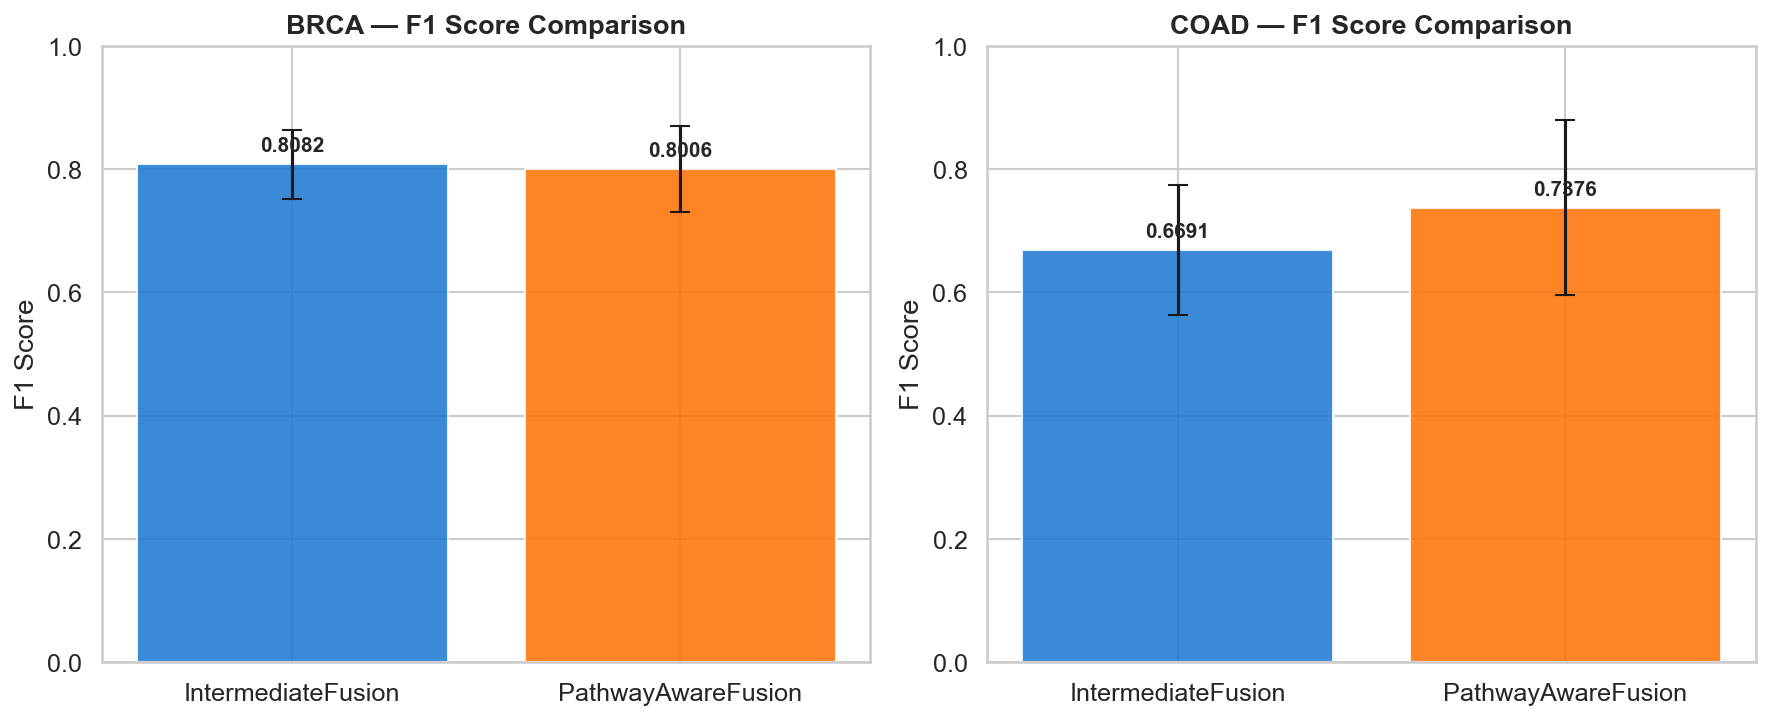

Saved: results/plots/pathway_vs_plain_comparison.png/pdf


In [5]:
# Grouped bar chart: F1 comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = {'IntermediateFusion': '#1976D2', 'PathwayAwareFusion': '#FF6F00'}

for i, cancer in enumerate(['BRCA', 'COAD']):
    sub = comp_df[comp_df['Cancer'] == cancer]
    ax = axes[i]
    means = sub.groupby('Model')['F1'].mean()
    stds = sub.groupby('Model')['F1'].std()
    
    bars = ax.bar(means.index, means.values, yerr=stds.values,
                  color=[colors[m] for m in means.index],
                  edgecolor='white', capsize=5, alpha=0.85)
    ax.set_title(f'{cancer} \u2014 F1 Score Comparison', fontweight='bold', fontsize=13)
    ax.set_ylabel('F1 Score')
    ax.set_ylim(0, 1.0)
    
    for bar, val in zip(bars, means.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.4f}', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
os.makedirs('results/plots', exist_ok=True)
for ext in ['png', 'pdf']:
    plt.savefig(f'results/plots/pathway_vs_plain_comparison.{ext}',
                dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: results/plots/pathway_vs_plain_comparison.png/pdf')

### 3. Pathway Attention Scores

In [6]:
attn = pd.read_csv('results/enrichment/pathway_attention_scores.csv')
display(attn.head(20))

,rank,cancer_type,pathway,mean_attention_weight,std_attention_weight
0,1,GS-BRCA,Axon guidance,0.003735,0.001290
1,2,GS-BRCA,Graft-versus-host disease,0.003723,0.001810
2,3,GS-BRCA,IL-17 signaling pathway,0.003691,0.000829
3,4,GS-BRCA,Cocaine addiction,0.003684,0.000745
4,5,GS-BRCA,Primary bile acid biosynthesis,0.003666,0.001047
5,6,GS-BRCA,Ferroptosis,0.003640,0.000846
6,7,GS-BRCA,Progesterone-mediated oocyte maturation,0.003631,0.000719
7,8,GS-BRCA,Taurine and hypotaurine metabolism,0.003622,0.000482
8,9,GS-BRCA,Melanoma,0.003615,0.001203
9,10,GS-BRCA,Lysine degradation,0.003612,0.001290


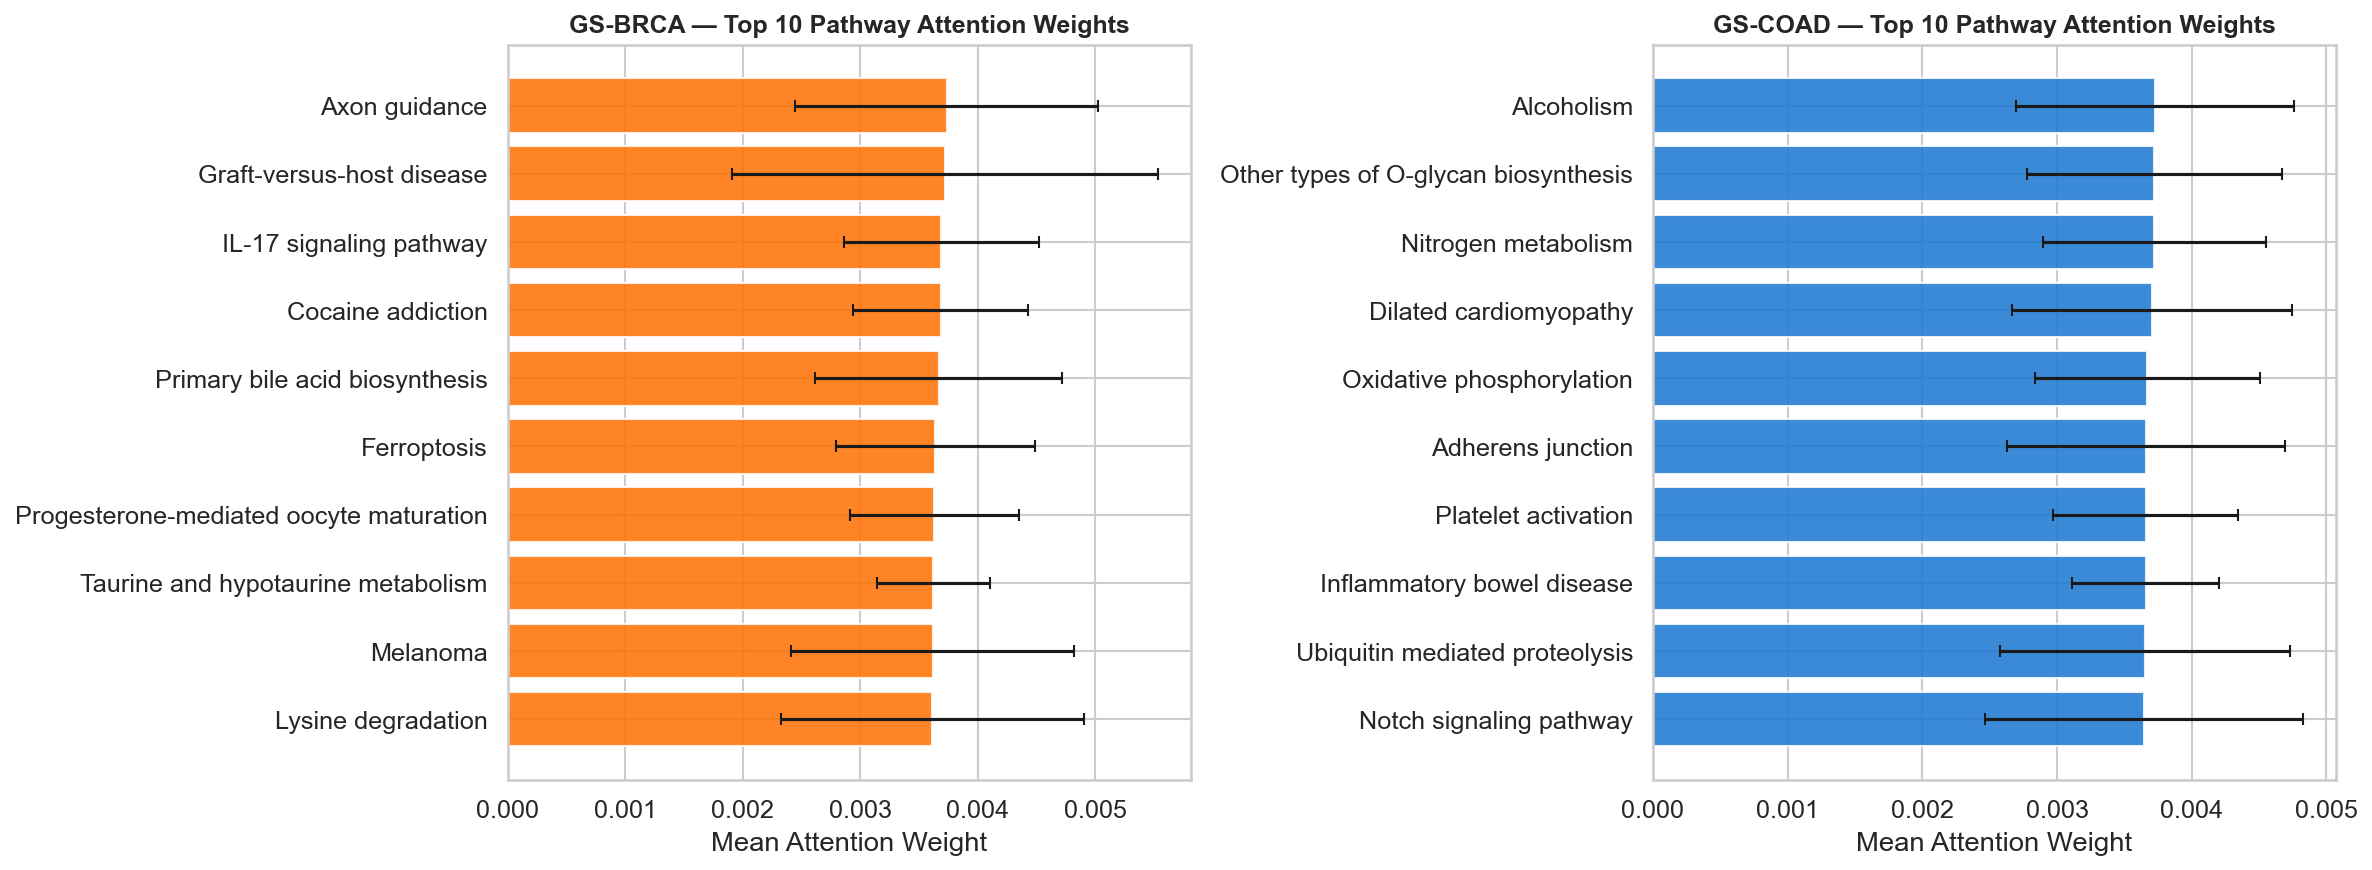

Saved: results/plots/pathway_attention_top10.png/pdf


In [7]:
# Horizontal bar plots of top-10 pathways per cancer type
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
bar_colors = ['#FF6F00', '#1976D2']

for i, ct in enumerate(attn['cancer_type'].unique()):
    sub = attn[attn['cancer_type'] == ct].head(10).iloc[::-1]  # reverse for horizontal
    ax = axes[i]
    ax.barh(sub['pathway'], sub['mean_attention_weight'],
            xerr=sub['std_attention_weight'], color=bar_colors[i],
            edgecolor='white', capsize=3, alpha=0.85)
    ax.set_title(f'{ct} \u2014 Top 10 Pathway Attention Weights',
                 fontweight='bold', fontsize=12)
    ax.set_xlabel('Mean Attention Weight')

plt.tight_layout()
for ext in ['png', 'pdf']:
    plt.savefig(f'results/plots/pathway_attention_top10.{ext}',
                dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: results/plots/pathway_attention_top10.png/pdf')

### 4. Key Findings

| Cancer | IntermediateFusion F1 | PathwayAwareFusion F1 | Delta | Conclusion |
|--------|----------------------|----------------------|-------|------------|
| BRCA   | 0.8082               | 0.8006               | -0.008 | Comparable \u2014 pathway priors don't degrade performance |
| COAD   | 0.6691               | 0.7376               | +0.069 | Pathway attention improves classification for smaller dataset |

**Interpretation:**
- For BRCA (large, 671 samples), the model has enough data to learn informative features directly \u2014 pathway priors add no benefit.
- For COAD (small, 260 samples), pathway grouping acts as a biological regularizer, guiding the model to focus on functionally coherent gene sets.
- Attention scores reveal biologically relevant pathways (Notch signaling, Inflammatory bowel disease for COAD).

**Academic research prototype. Not for clinical use.**